In [2]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [3]:
data = []
labels = []
file_name = []

path_dataset = "archive/tomato/train/"

target_classes = [
    "Tomato___Early_blight", 
    "Tomato___Septoria_leaf_spot", 
    "Tomato___healthy"
]

for sub_folder in target_classes:
    path_sub_folder = os.path.join(path_dataset, sub_folder)
    
    sub_folder_files = os.listdir(path_sub_folder)
    
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(path_sub_folder, filename)
        img = cv.imread(img_path)
        
        if img is not None:
            img = img.astype(np.uint8)
            
            data.append(img)
            labels.append(sub_folder)
            file_name.append(filename)
            
data = np.array(data, dtype=object)
labels = np.array(labels)

In [4]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img, dtype=np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas
 
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
], dtype=np.float32)

kernelSharpening = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def gabung_tepi(*edges):
    gabungan = np.zeros_like(edges[0], dtype=np.float32)
    for e in edges:
        gabungan += e.astype(np.float32)
    gabungan = gabungan * 255.0 / np.max(gabungan)
    return np.clip(gabungan, 0, 255).astype(np.uint8)

sobelx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]],dtype=np.float32)
sobely = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]], dtype=np.float32)

prewittx = np.array([[-1, 0, 1],
                      [-1, 0, 1], 
                      [-1, 0, 1]], dtype=np.float32)
prewitty = np.array([[1, 1, 1], 
                      [0, 0, 0], 
                      [-1, -1, -1]], dtype=np.float32)

robertsx = np.array([[1, 0], 
                     [0, -1]], dtype=np.float32)
robertsy = np.array([[0, 1], 
                     [-1, 0]], dtype=np.float32)

def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.sum(region) // area
                    
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    region_flat = np.sort(region.ravel())
                    canvas[i, j] = region_flat[(size * size) // 2]
                    
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                            
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                            
                    canvas[i, j] = mode_val
                    
    return canvas

def ekualisasi_manual(image):
    hist, _ = np.histogram(image, 256, [0, 256])
    cdf = np.cumsum(hist)
    cdf_min = np.min(cdf)
    baris, kolom = image.shape
    total_pixel = baris * kolom

    if total_pixel == cdf_min:
        return np.zeros_like(image)
        
    cdf_normalized = np.round((cdf - cdf_min) * 255 / (total_pixel - cdf_min))
    
    hasil_eq = np.zeros_like(image)
    for i in range(baris):
        for j in range(kolom):
            hasil_eq[i, j] = cdf_normalized[int(image[i, j])]
            
    return hasil_eq

Memproses Masking HSV -> Grayscale -> Ekualisasi -> Median Filter...
Peringatan: Proses ini mungkin butuh waktu lama karena looping piksel manual.
Selesai memproses 10 dari 3000 gambar...
Selesai memproses 20 dari 3000 gambar...
Selesai memproses 30 dari 3000 gambar...
Selesai memproses 40 dari 3000 gambar...
Selesai memproses 50 dari 3000 gambar...
Selesai memproses 60 dari 3000 gambar...
Selesai memproses 70 dari 3000 gambar...
Selesai memproses 80 dari 3000 gambar...
Selesai memproses 90 dari 3000 gambar...
Selesai memproses 100 dari 3000 gambar...
Selesai memproses 110 dari 3000 gambar...
Selesai memproses 120 dari 3000 gambar...
Selesai memproses 130 dari 3000 gambar...
Selesai memproses 140 dari 3000 gambar...
Selesai memproses 150 dari 3000 gambar...
Selesai memproses 160 dari 3000 gambar...
Selesai memproses 170 dari 3000 gambar...
Selesai memproses 180 dari 3000 gambar...
Selesai memproses 190 dari 3000 gambar...
Selesai memproses 200 dari 3000 gambar...
Selesai memproses 210 

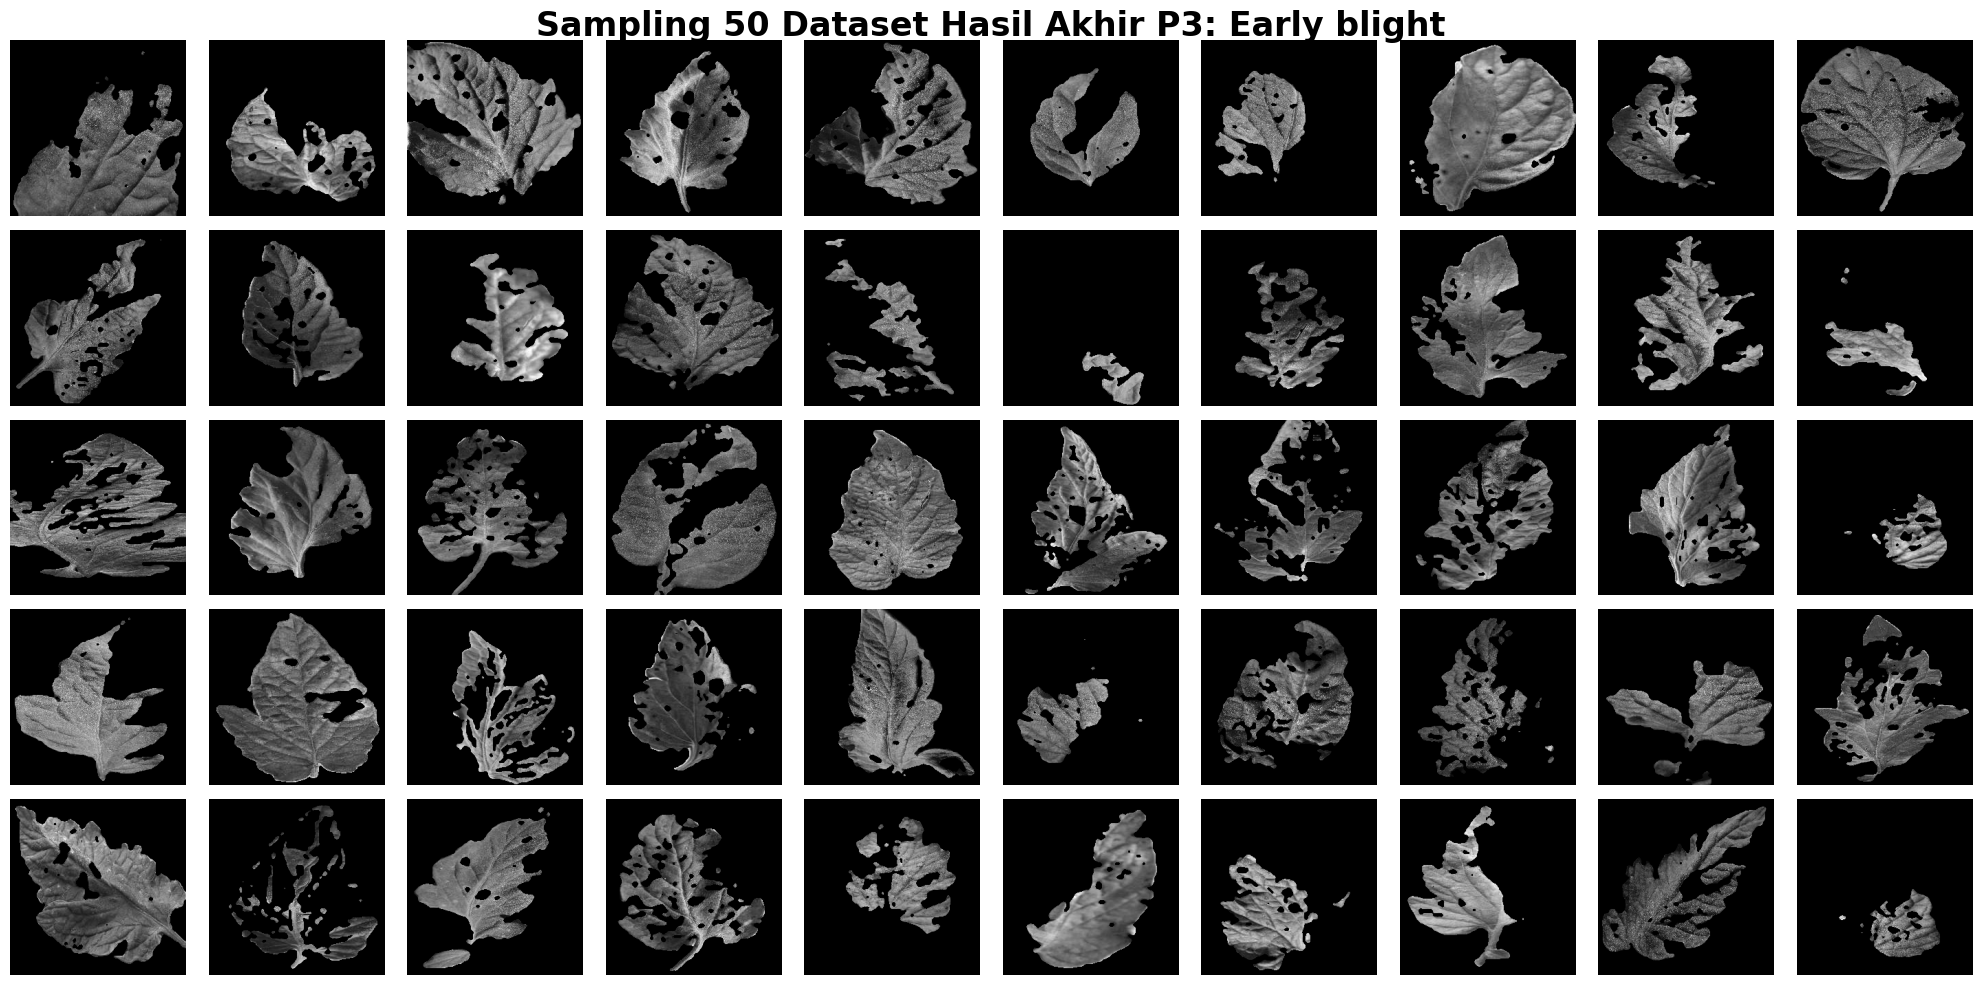

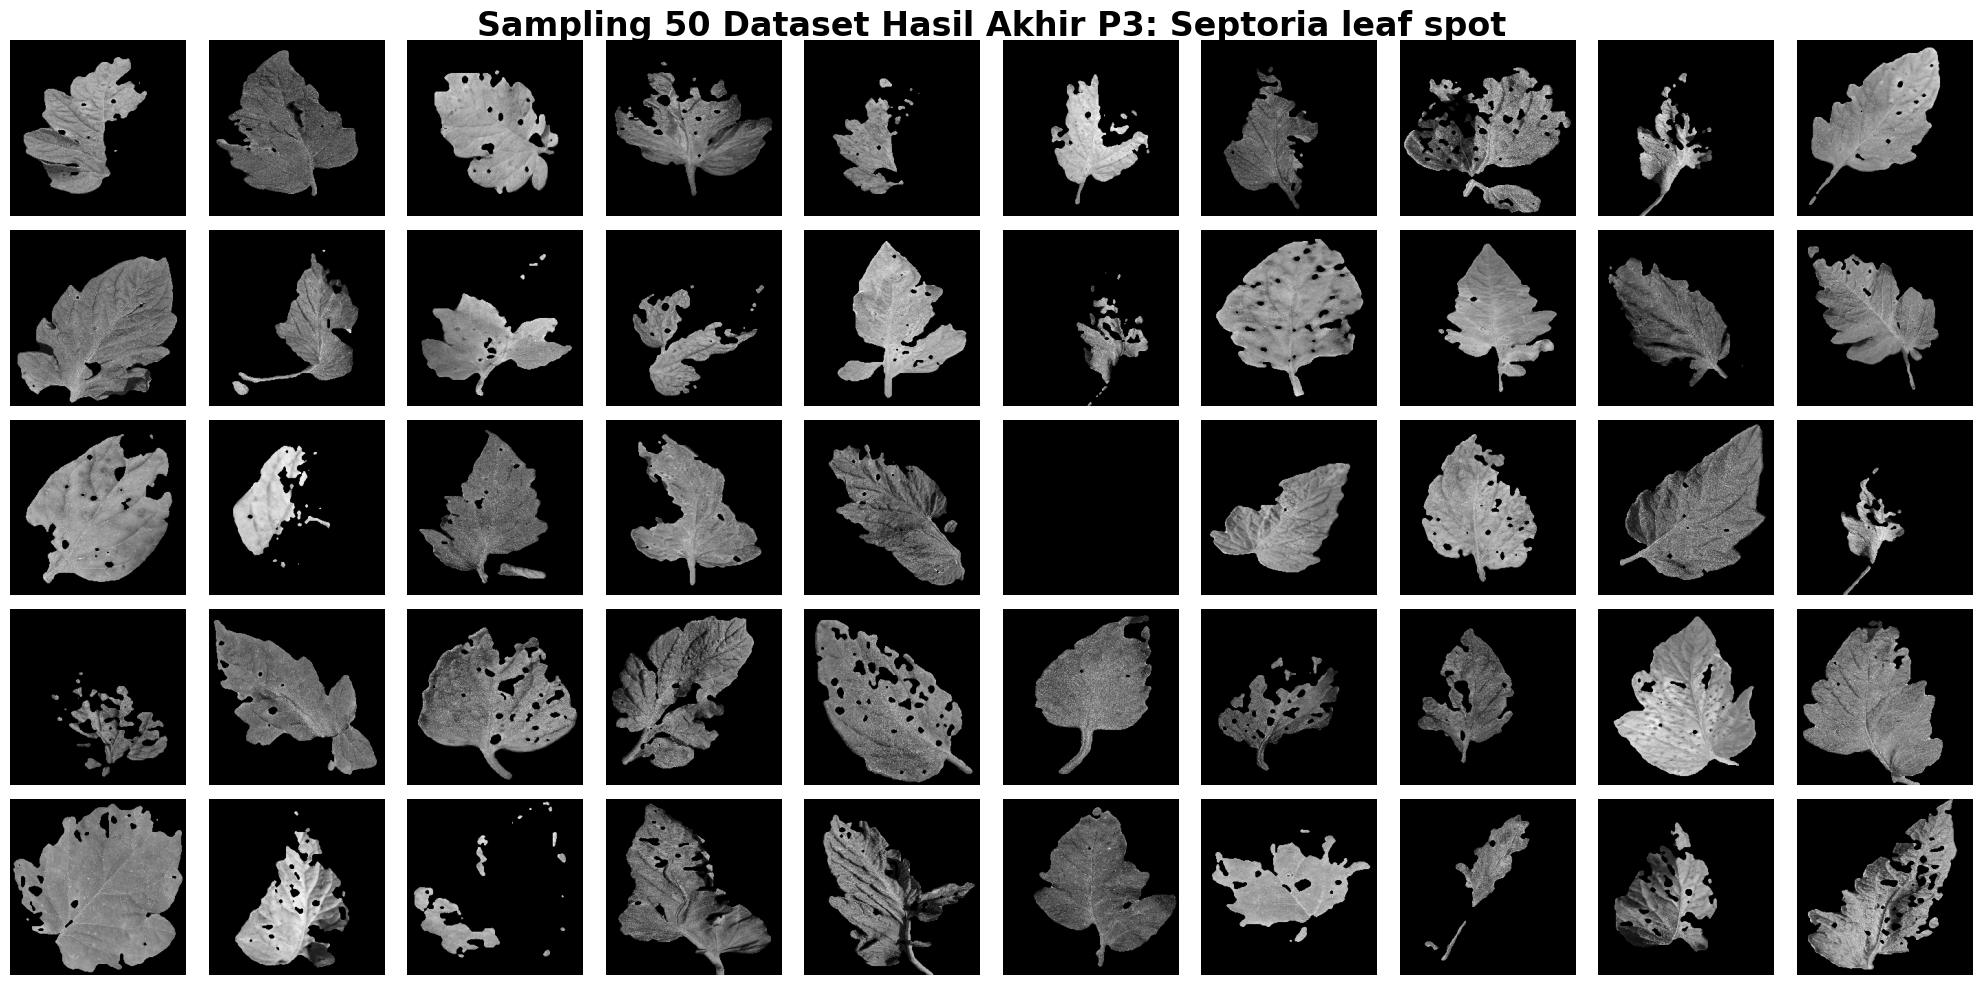

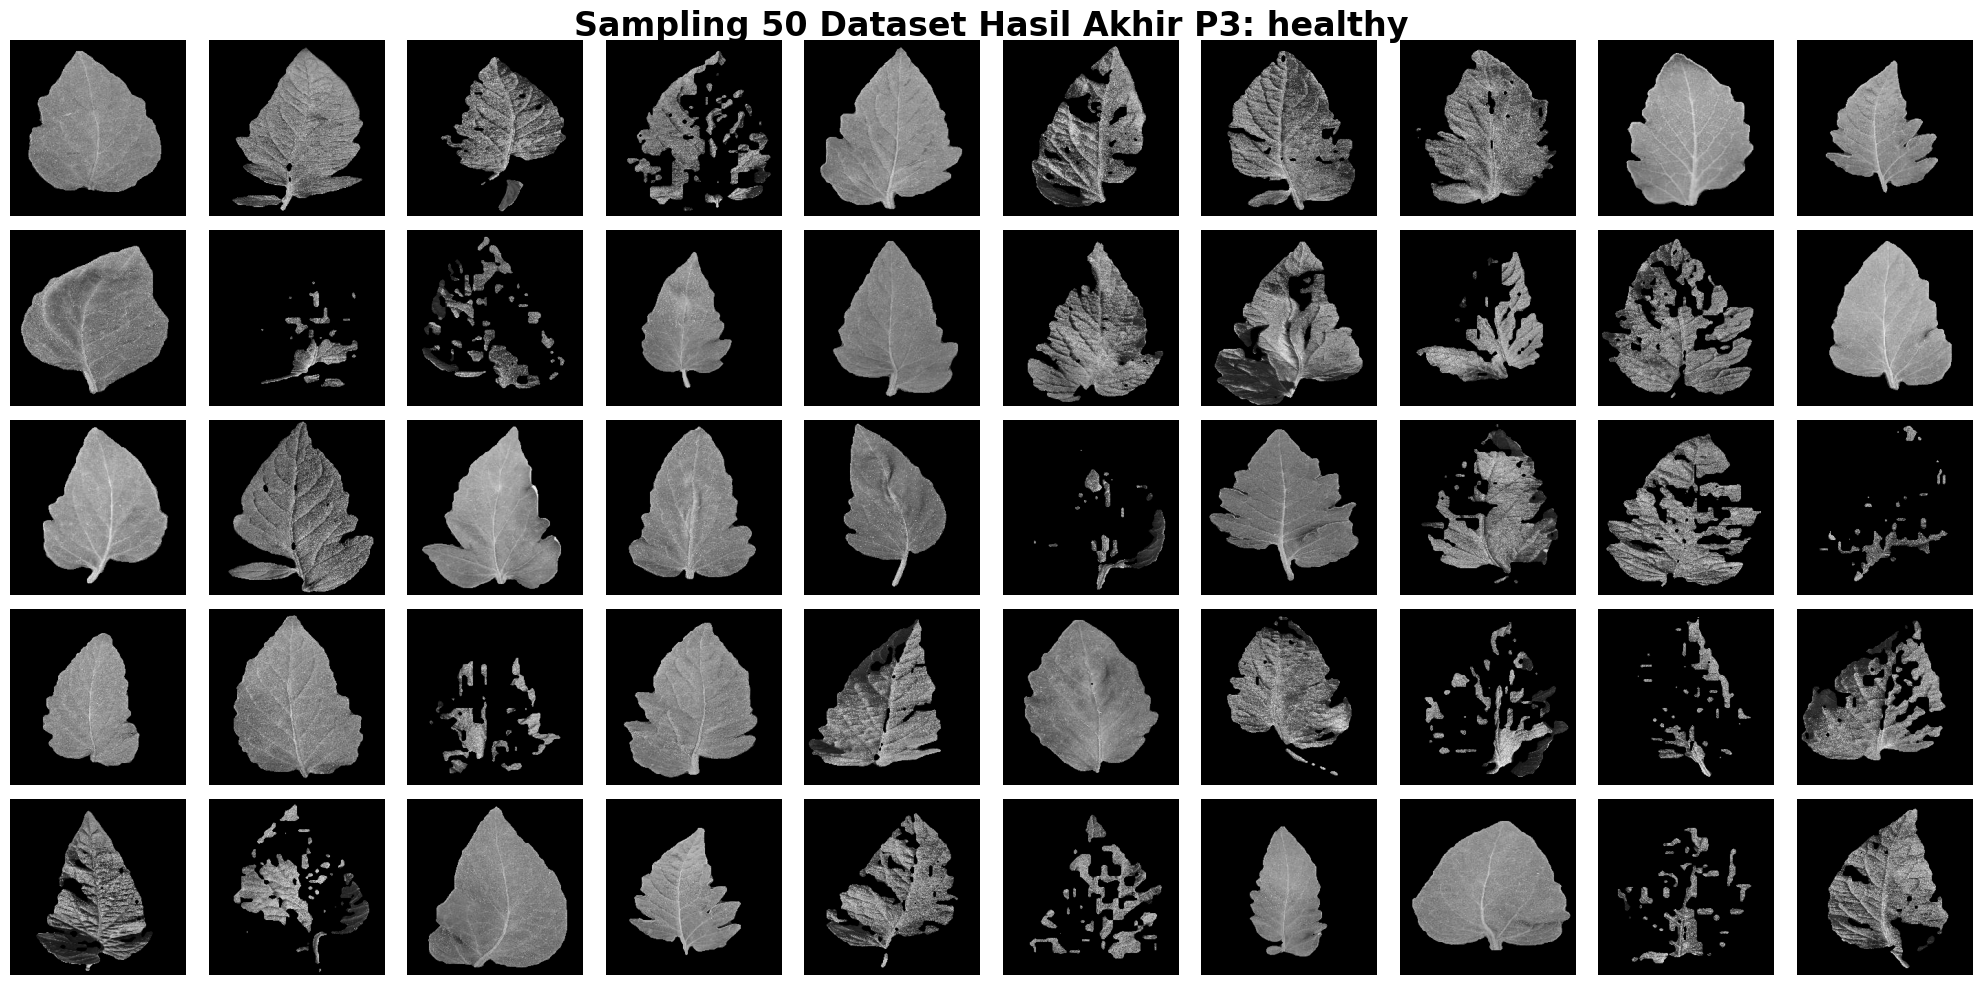

In [5]:
# =========================================================================
# === PROSES PREPROCESSING 3 (MASKING -> EKUALISASI -> MEDIAN) ===
# =========================================================================
data_p3 = []

print("Memproses Masking HSV -> Grayscale -> Ekualisasi -> Median Filter...")
print("Peringatan: Proses ini mungkin butuh waktu lama karena looping piksel manual.")

for idx_img in range(len(data)):
    img_bgr = data[idx_img].astype(np.uint8)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    tinggi, lebar = img_rgb.shape[:2]
    mask_fg = np.zeros((tinggi, lebar), dtype=np.uint8)

    for i in range(tinggi):
        for j in range(lebar):
            r = int(img_rgb[i, j, 0])
            g = int(img_rgb[i, j, 1])
            b = int(img_rgb[i, j, 2])
            
            if (g > r + 10) and (g > b + 10):
                mask_fg[i, j] = 255
            else:
                mask_fg[i, j] = 0

    mask_fg_clean = filter(mask_fg, 5, 'median')

    daun_removed = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

    for i in range(tinggi):
        for j in range(lebar):
            if mask_fg_clean[i, j] == 255:
                daun_removed[i, j, 0] = img_rgb[i, j, 0]
                daun_removed[i, j, 1] = img_rgb[i, j, 1]
                daun_removed[i, j, 2] = img_rgb[i, j, 2]
            else:
                daun_removed[i, j, 0] = 0
                daun_removed[i, j, 1] = 0
                daun_removed[i, j, 2] = 0
    
    daun_gray = cv.cvtColor(daun_removed, cv.COLOR_RGB2GRAY)

    
    data_p3.append(daun_gray)
    
    # Tracker Progress biar lu tau programnya nggak nge-hang
    if (idx_img + 1) % 10 == 0:
        print(f"Selesai memproses {idx_img + 1} dari {len(data)} gambar...")

data_p3 = np.array(data_p3, dtype=object)

# =========================================================================
# === VISUALISASI HASIL AKHIR (MEDIAN FILTER SAJA) ===
# =========================================================================
print("Pemrosesan Selesai! Menampilkan 50 sampel hasil akhir (Prepro 3)...")

for nama_kelas in target_classes:
    indeks_kelas = []
    for idx in range(len(labels)):
        if labels[idx] == nama_kelas:
            indeks_kelas.append(idx)
            
    fig, axes = plt.subplots(5, 10, figsize=(20, 10))
    judul_bersih = nama_kelas.replace("Tomato___", "").replace("_", " ")
    fig.suptitle(f"Sampling 50 Dataset Hasil Akhir P3: {judul_bersih}", fontsize=24, fontweight='bold')
    
    for i, ax in enumerate(axes.flat):
        if i < len(indeks_kelas):
            img_tampil = data_p3[indeks_kelas[i]].astype(np.uint8)
            ax.imshow(img_tampil, cmap='gray')
            
        ax.axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.95) 
    plt.show()
    
# =========================================================================

In [6]:
print("Memulai proses Ekstraksi Fitur GLCM sesuai template...")

# === 1. DEFINE FUNCTIONS SESUAI TEMPLATE ===
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # --- PERBAIKAN DI SINI ---
    # Memaksa tipe data gambar menjadi uint8 agar skimage tidak error
    img_safe = image.astype(np.uint8)
    
    # Mengembalikan matrix glcm dari image 
    glcm = graycomatrix(img_safe, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

# === 2. EXTRACT MATRIX GLCM UNTUK SETIAP DERAJAT ===
dataPreprocessed = data_p3  # Memetakan hasil preprocessing akhir lu ke template

Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

# === 3. COPAS ARRAY PENAMPUNG DARI TEMPLATE ===
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

# === 4. HITUNG PROPERTI TEKSTUR PER DERAJAT ===
for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(dataPreprocessed)):  
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

# === 5. WRITE THE EXTRACTION'S RESULTS TO CSV ===
dataTable = {
    'Filename': file_name, 
    'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_p3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_p3.csv')
print("Ekstraksi Fitur Berhasil Selesai & Disimpan ke CSV!")
hasilEkstrak

Memulai proses Ekstraksi Fitur GLCM sesuai template...
Ekstraksi Fitur Berhasil Selesai & Disimpan ke CSV!


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly...,Tomato___Early_blight,305.761887,363.727428,276.009038,325.980715,0.587876,0.576996,0.593142,0.581234,...,0.298634,0.294212,0.542827,0.540628,0.546474,0.542413,0.916383,0.900682,0.924548,0.910989
1,0034a551-9512-44e5-ba6c-827f85ecc688___RS_Erly...,Tomato___Early_blight,124.375398,175.655579,127.222886,189.321399,0.779479,0.759570,0.766855,0.759180,...,0.540318,0.534621,0.734717,0.731286,0.735063,0.731178,0.954952,0.936553,0.953921,0.931617
2,004cbe60-8ff9-4965-92df-e86694d5e9ba___RS_Erly...,Tomato___Early_blight,750.877895,863.599216,733.300613,904.860454,0.477395,0.467246,0.476388,0.465349,...,0.191590,0.187285,0.439608,0.434625,0.437710,0.432764,0.906795,0.892826,0.909111,0.887706
3,0114f7b3-7f56-4bef-aa47-7a82da142d4b___RS_Erly...,Tomato___Early_blight,223.609406,277.525352,198.424020,277.406813,0.690864,0.682398,0.691789,0.682203,...,0.439757,0.434876,0.662866,0.658975,0.663142,0.659451,0.948773,0.936574,0.954543,0.936601
4,011aa278-a39e-40b0-b6e4-2e2f835889f0___RS_Erly...,Tomato___Early_blight,563.669547,685.417762,606.606526,670.945575,0.588107,0.576952,0.585443,0.575577,...,0.306040,0.301007,0.554328,0.548487,0.553208,0.548641,0.902967,0.882207,0.895576,0.884694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,ff354b62-5981-43d1-8cfe-ac58bc20ca20___GH_HL L...,Tomato___healthy,224.201379,371.410473,277.646415,311.306790,0.574366,0.555999,0.567453,0.558813,...,0.267870,0.265272,0.519254,0.513768,0.517562,0.515046,0.971715,0.953164,0.964972,0.960743
2996,ff774aec-2504-4d11-8a61-2fd74c689a6f___RS_HL 9...,Tomato___healthy,331.386703,441.900192,364.924173,442.521584,0.919154,0.915533,0.918362,0.915698,...,0.839409,0.834475,0.916851,0.913311,0.916193,0.913496,0.854705,0.806951,0.840000,0.806680
2997,ff8b36d5-feaf-4d2d-8126-18670a312657___RS_HL 0...,Tomato___healthy,777.136397,984.211365,895.245987,1054.131150,0.717996,0.712271,0.717324,0.712508,...,0.502762,0.496411,0.708981,0.704257,0.709057,0.704564,0.896862,0.869691,0.881156,0.860433
2998,ffb39943-eabb-42cf-ad09-b17019e46d66___RS_HL 9...,Tomato___healthy,799.749663,921.175271,763.133824,850.605552,0.616211,0.610879,0.618240,0.612019,...,0.359443,0.354406,0.598080,0.594766,0.599535,0.595320,0.900918,0.886091,0.905454,0.894818


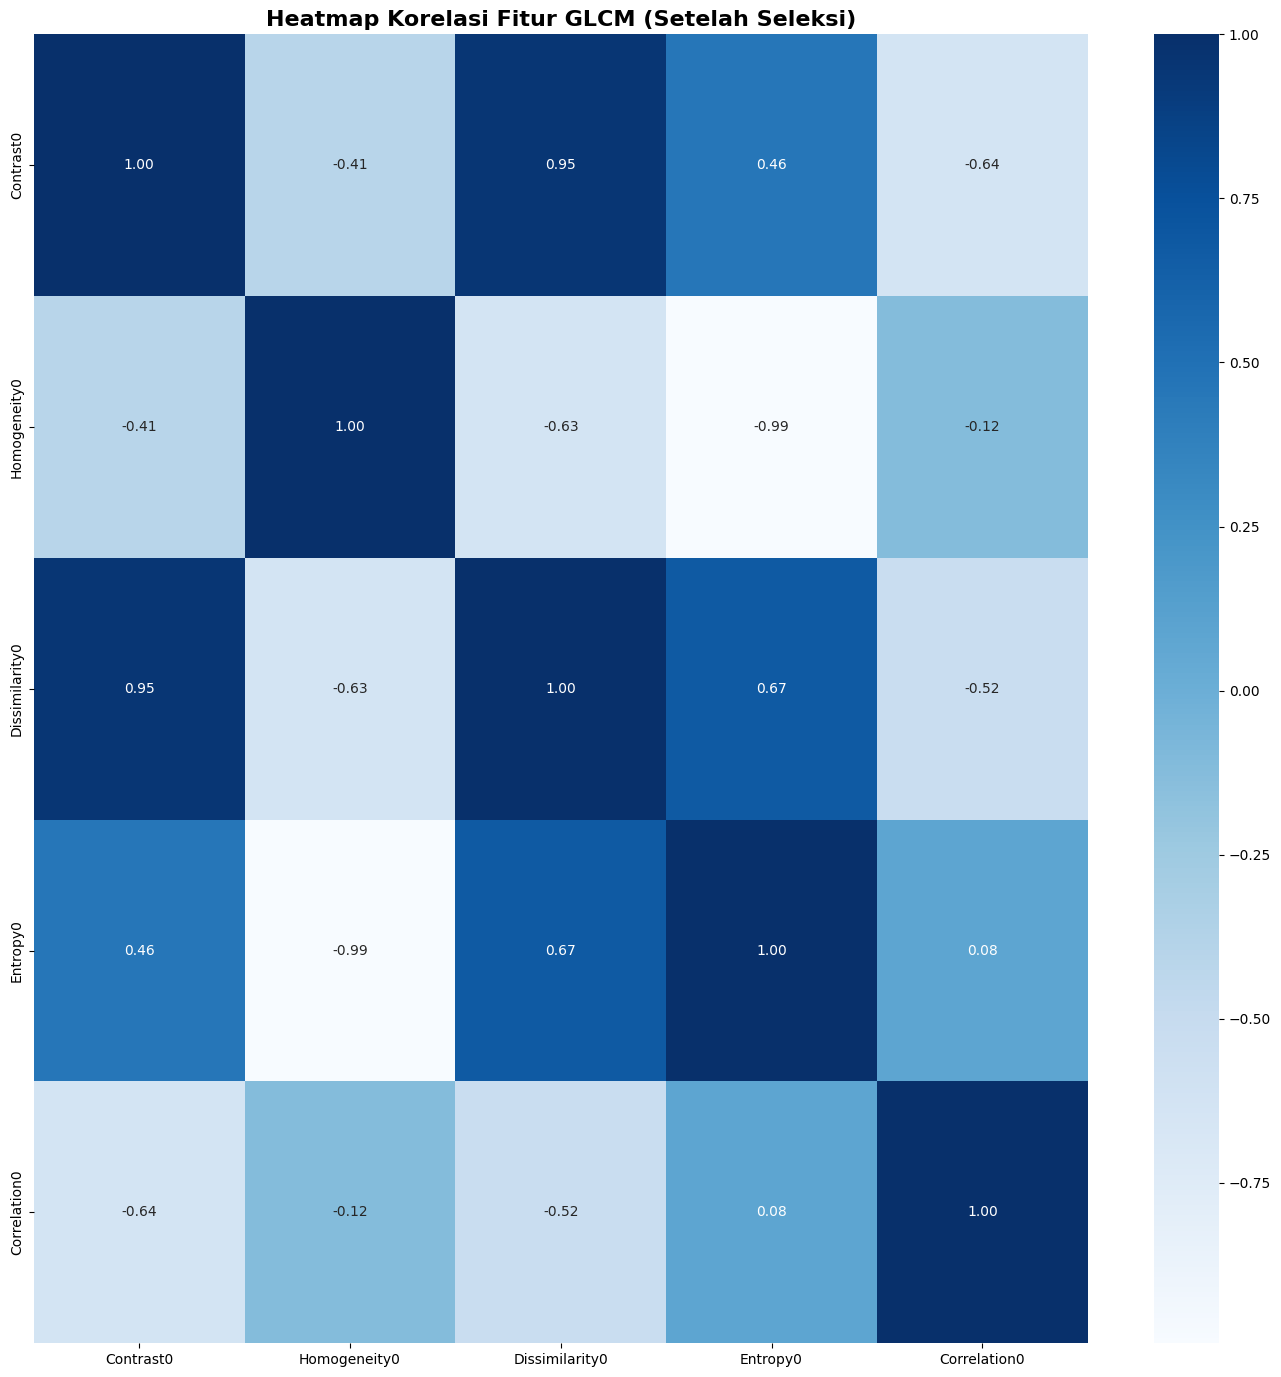

In [7]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur GLCM (Setelah Seleksi)', fontsize=16, fontweight='bold')
plt.show()

In [8]:
# === 1. SPLITTING DATA ===
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

# === 2. FEATURE NORMALIZATION ===
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

(2400, 5)
(600, 5)


In [9]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [10]:
# === 1. TRAIN & EVALUATE RANDOM FOREST ===
print("==================================================")
print("              RANDOM FOREST CLASSIFIER            ")
print("==================================================")
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_rf = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_train_rf)

print("\n------Testing Set------")
y_pred_test_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_test_rf)

              RANDOM FOREST CLASSIFIER            
------Training Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.98      0.96      0.97       783
Tomato___Septoria_leaf_spot       0.95      0.97      0.96       803
           Tomato___healthy       0.98      0.98      0.98       814

                   accuracy                           0.97      2400
                  macro avg       0.97      0.97      0.97      2400
               weighted avg       0.97      0.97      0.97      2400

[[750  28   5]
 [ 17 778   8]
 [  1  14 799]]
Accuracy: 0.9695833333333334

------Testing Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.79      0.82      0.80       217
Tomato___Septoria_leaf_spot       0.73      0.67      0.70       197
           Tomato___healthy       0.84      0.89      0.87       186

                   accuracy                           0.79  

In [11]:
# === 2. TRAIN & EVALUATE SVM ===
print("\n==================================================")
print("                   SVM CLASSIFIER                 ")
print("==================================================")
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_svm = svm.predict(X_train)
generateClassificationReport(y_train, y_pred_train_svm)

print("\n------Testing Set------")
y_pred_test_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_test_svm)


                   SVM CLASSIFIER                 
------Training Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.79      0.77      0.78       783
Tomato___Septoria_leaf_spot       0.70      0.72      0.71       803
           Tomato___healthy       0.90      0.88      0.89       814

                   accuracy                           0.79      2400
                  macro avg       0.79      0.79      0.79      2400
               weighted avg       0.79      0.79      0.79      2400

[[604 160  19]
 [159 579  65]
 [  3  92 719]]
Accuracy: 0.7925

------Testing Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.78      0.78      0.78       217
Tomato___Septoria_leaf_spot       0.70      0.71      0.71       197
           Tomato___healthy       0.90      0.88      0.89       186

                   accuracy                           0.79       600
  

In [12]:
# === 3. TRAIN & EVALUATE KNN ===
print("\n==================================================")
print("                   KNN CLASSIFIER                 ")
print("==================================================")
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_knn = knn.predict(X_train)
generateClassificationReport(y_train, y_pred_train_knn)

print("\n------Testing Set------")
y_pred_test_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_test_knn)


                   KNN CLASSIFIER                 
------Training Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.84      0.84      0.84       783
Tomato___Septoria_leaf_spot       0.79      0.78      0.79       803
           Tomato___healthy       0.90      0.93      0.92       814

                   accuracy                           0.85      2400
                  macro avg       0.85      0.85      0.85      2400
               weighted avg       0.85      0.85      0.85      2400

[[654 113  16]
 [111 628  64]
 [  9  50 755]]
Accuracy: 0.84875

------Testing Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.75      0.72      0.74       217
Tomato___Septoria_leaf_spot       0.65      0.64      0.64       197
           Tomato___healthy       0.84      0.89      0.86       186

                   accuracy                           0.75       600
 

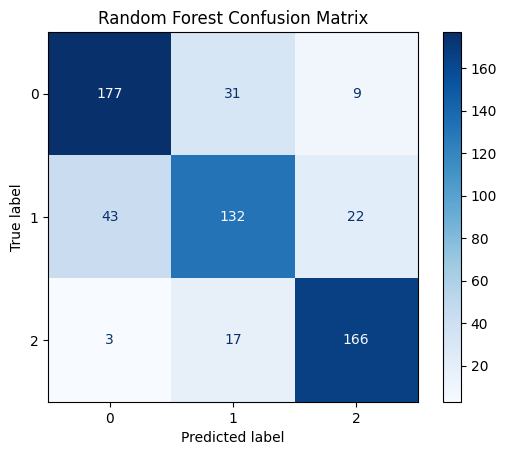

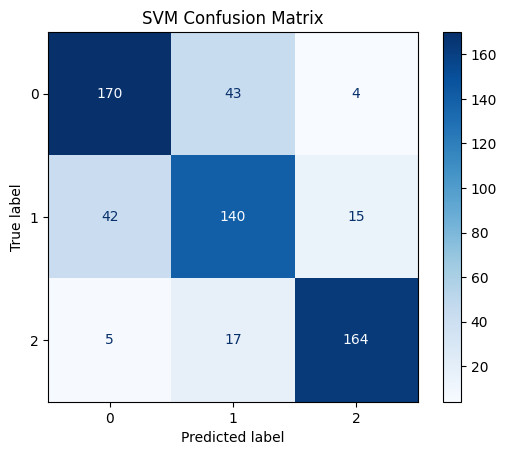

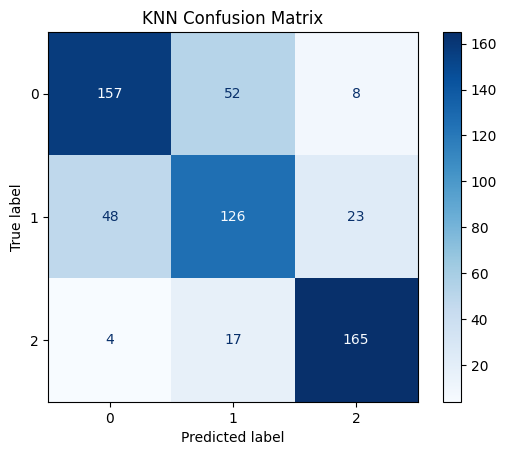

In [13]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")